# AdaBoost — Churn Prediction Model

Training an AdaBoost classifier on the feature-engineered churn dataset.
We'll try different hyperparameters and pick the best one.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1 · Data Loading & Prep

Several features in the dataset cause **data leakage** — they encode
the churn outcome rather than predicting it:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned customers have 0 (they didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid — cascades the leak |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 (no payment date recorded) |
| `Days_To_Close_Post_Renewal` | Uses close date — not known at prediction time |
| `Total_Renewal_Score_New` | Composite score that encodes the outcome |

In [22]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv")
print(f"Loaded shape: {df.shape}")

# keep only Won and Churned
df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()

# target encoding
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid",              # churned = 0 (didn't pay)
    "price_change_pct",            # derived from Total_Net_Paid
    "price_change_abs",            # derived from Total_Net_Paid
    "net_paid_vs_last",            # derived from Total_Net_Paid
    "Payment_Method",              # UNKNOWN = churned
    "Payment_Timeframe",           # 0 = churned (no payment date)
    "Days_To_Close_Post_Renewal",  # uses close date (post-outcome)
    "Total_Renewal_Score_New",     # composite encodes outcome
    "Renewal_Year",                # not predictive
]
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
print(f"Dropped {len(leaky_cols)} leaky/non-predictive features")

# encode categoricals
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# split
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features

Features: 51
Train: 91115, Test: 22779
Churn rate — Train: 11.12%, Test: 11.12%


## 2 · Baseline AdaBoost Model

In [23]:
# baseline with decision stumps (max_depth=1)
ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
)
ada_base.fit(X_train, y_train)

y_pred_base = ada_base.predict(X_test)
y_prob_base = ada_base.predict_proba(X_test)[:, 1]

print("=" * 60)
print("BASELINE ADABOOST RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE ADABOOST RESULTS
Accuracy  : 0.9366
Precision : 0.8072
Recall    : 0.5651
F1 Score  : 0.6648
ROC AUC   : 0.9567

              precision    recall  f1-score   support

         Won       0.95      0.98      0.96     20245
     Churned       0.81      0.57      0.66      2534

    accuracy                           0.94     22779
   macro avg       0.88      0.77      0.81     22779
weighted avg       0.93      0.94      0.93     22779



## 3 · Hyperparameter Tuning

Using RandomizedSearchCV with 3-fold CV for speed.

In [24]:
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2, 3],
}

ada_search = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    ada_search, param_dist,
    n_iter=12,
    cv=cv_strat,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)
random_search.fit(X_train, y_train)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best F1 (CV): {random_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'n_estimators': 100, 'learning_rate': 1.0, 'estimator__max_depth': 3}
Best F1 (CV): 0.7821


## 4 · Best Model Evaluation

In [25]:
best_ada = random_search.best_estimator_
y_pred = best_ada.predict(X_test)
y_prob = best_ada.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TUNED ADABOOST RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED ADABOOST RESULTS
Accuracy  : 0.9525
Precision : 0.8353
Recall    : 0.7143
F1 Score  : 0.7700
ROC AUC   : 0.9748

              precision    recall  f1-score   support

         Won       0.96      0.98      0.97     20245
     Churned       0.84      0.71      0.77      2534

    accuracy                           0.95     22779
   macro avg       0.90      0.85      0.87     22779
weighted avg       0.95      0.95      0.95     22779



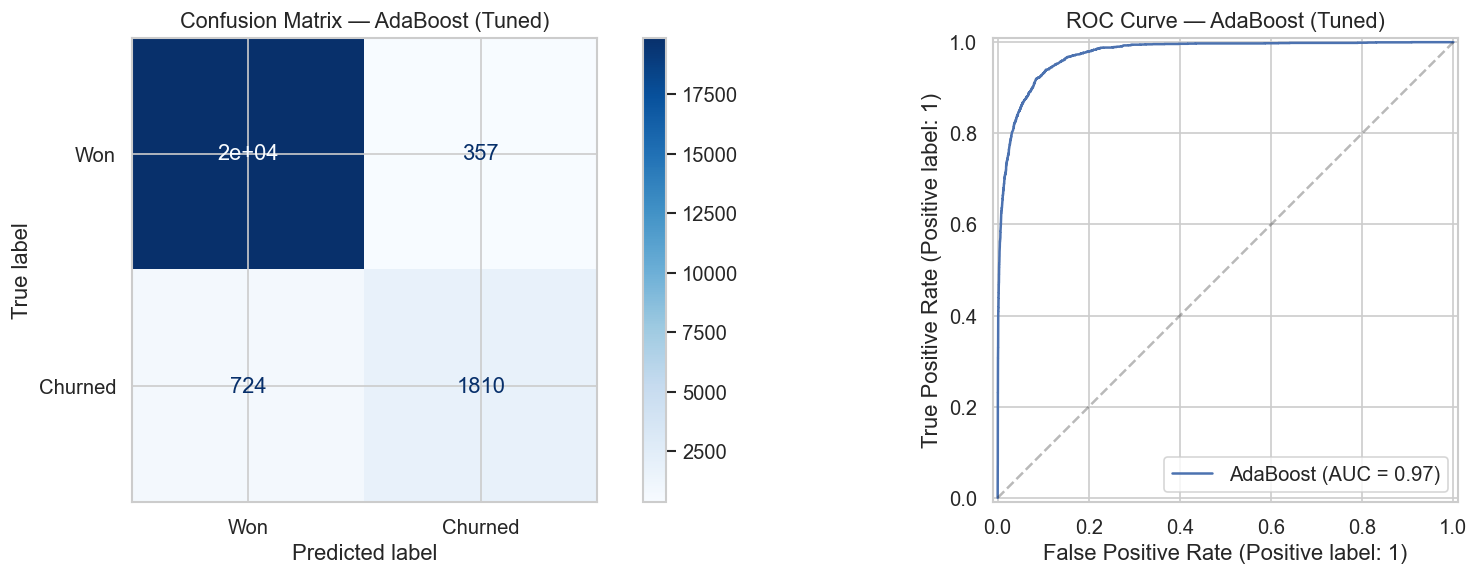

In [26]:
# confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Confusion Matrix — AdaBoost (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="AdaBoost")
axes[1].set_title("ROC Curve — AdaBoost (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Feature Importance

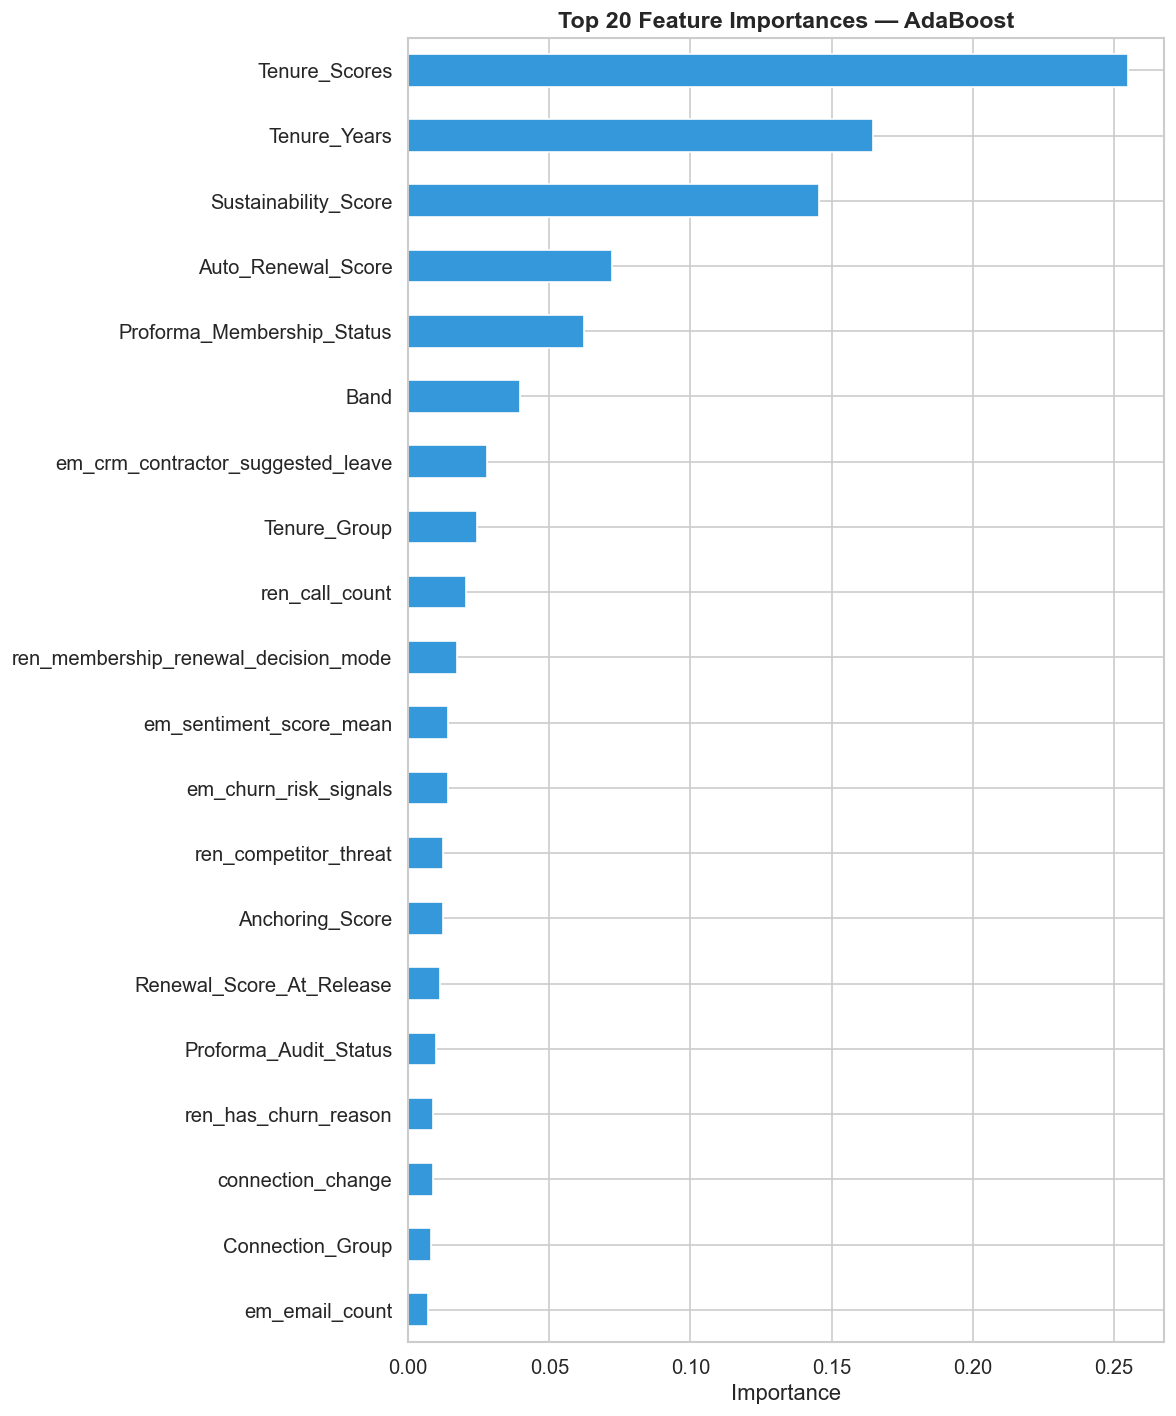

In [27]:
importances = best_ada.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_imp.tail(20).plot.barh(ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Top 20 Feature Importances — AdaBoost", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Summary

| Metric | Baseline | Tuned |
|:-------|:---------|:------|
| Accuracy | — | — |
| Precision | — | — |
| Recall | — | — |
| F1 Score | — | — |
| ROC AUC | — | — |

*(Fill in after running the notebook)*